# Explore here

In [3]:
# Your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [4]:
main_df = pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv")

In [5]:
df_encoded = pd.get_dummies(main_df, drop_first=True)

train_df, test_df = train_test_split(df_encoded, random_state=42)

In [6]:
X = df_encoded.drop("charges", axis=1)
y = df_encoded["charges"]

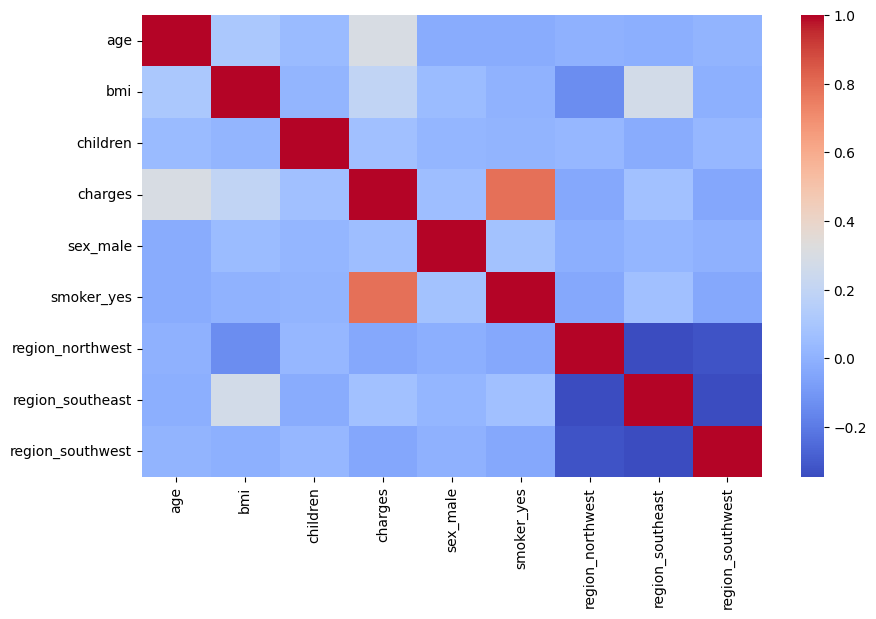

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=False, cmap="coolwarm")
plt.show()


In [8]:
train_df, test_df = train_test_split(main_df, random_state=42)
train_df = pd.get_dummies(train_df, drop_first=True)
train_df

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
693,24,23.655,0,2352.96845,True,False,True,False,False
1297,28,26.510,2,4340.44090,False,False,False,True,False
634,51,39.700,1,9391.34600,True,False,False,False,True
1022,47,36.080,1,42211.13820,True,True,False,True,False
178,46,28.900,2,8823.27900,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,4561.18850,False,False,False,False,False
1130,39,23.870,5,8582.30230,False,False,False,True,False
1294,58,25.175,0,11931.12525,True,False,False,False,False
860,37,47.600,2,46113.51100,False,True,False,False,True


In [9]:
train_df.isna().sum()
X_train = train_df.drop(columns=['charges'])
y_train= train_df['charges']

In [10]:
linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [11]:
train_preds= linreg_model.predict(X_train)

Text(0, 0.5, 'predict')

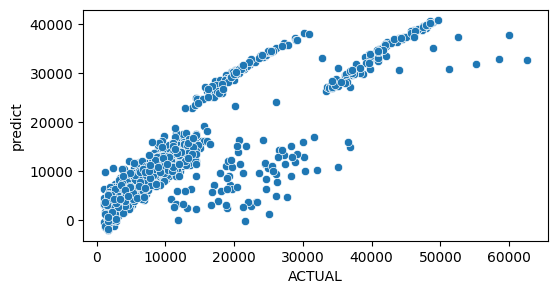

In [12]:
plt.figure(figsize=(6,3))
sns.scatterplot(x= y_train, y= train_preds)
#sns.scatterplot(x=np.linespace(0,5000),y=np.linespace(0,5000))
plt.xlabel("ACTUAL")
plt.ylabel("predict")

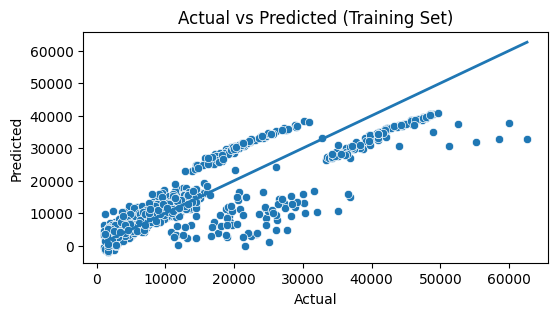

In [13]:
plt.figure(figsize=(6,3))

# Scatter: Actual vs Predicted
sns.scatterplot(x=y_train, y=train_preds)

# Reference line (perfect predictions)
plt.plot([y_train.min(), y_train.max()],
         [y_train.min(), y_train.max()],
         linewidth=2)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Training Set)")
plt.show()

In [14]:
mae = mean_absolute_error(y_train, train_preds)
mse = mean_squared_error(y_train, train_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, train_preds)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 4183.153367011969
MSE: 37004502.18409475
RMSE: 6083.132596294014
R²: 0.7449555328228536


In [15]:
train_residuls = train_preds - y_train

<Axes: xlabel='charges', ylabel='Count'>

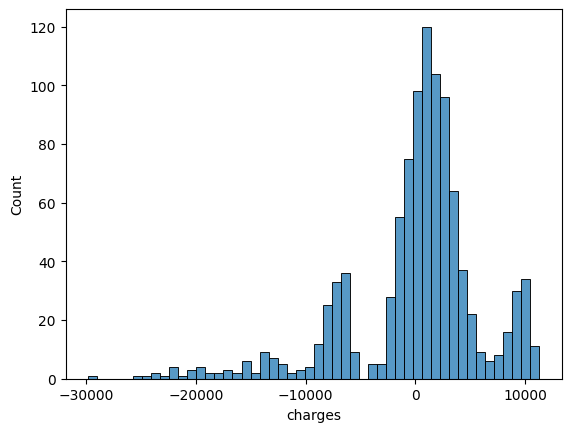

In [16]:
sns.histplot(train_residuls)

In [17]:
temp_residuls = train_residuls.reset_index(drop=True)

In [18]:
train_residuls = train_preds - y_train

Text(0.5, 1.0, 'scatter plot')

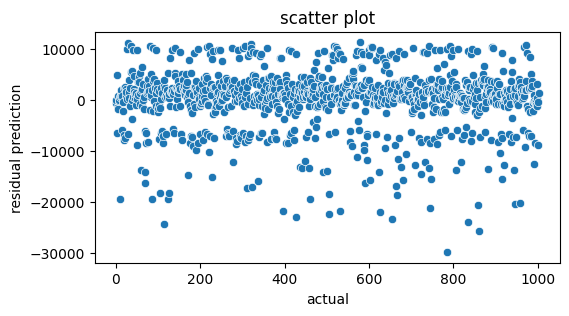

In [19]:
plt.figure(figsize=(6,3))
sns.scatterplot(x=temp_residuls.index, y= temp_residuls)
plt.xlabel("actual")
plt.ylabel("residual prediction")
plt.title("scatter plot")

In [20]:
#test data
X_test = test_df.drop(columns=['charges'])
y_test= ['charges']

In [21]:
X_test= pd.get_dummies(X_test)
X_test= X_test[X_train.columns]

In [22]:
test_pred= linreg_model.predict(X_test)

In [23]:
X_train.mean() * linreg_model.coef_

age                 10191.586546
bmi                 10368.056235
children              471.151562
sex_male               23.015901
smoker_yes           4853.302285
region_northwest      -87.105245
region_southeast     -201.769105
region_southwest     -211.850327
dtype: float64